# Tag List effect on ratings : Sheryl Boateng

In [274]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

## Data Statistics

In [275]:
makeup_data = pd.read_csv("/Users/sherylboateng/Desktop/TEPP_Data_Project/data/processed/clean_makeup.csv")

makeup_data.info()
makeup_data.describe().round()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            931 non-null    int64  
 1   brand         919 non-null    object 
 2   name          931 non-null    object 
 3   category      507 non-null    object 
 4   product_type  931 non-null    object 
 5   price         917 non-null    float64
 6   currency      368 non-null    object 
 7   tag_list      931 non-null    object 
 8   rating        340 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 65.6+ KB


,id,price,rating
count,931.0,917.0,340.0
mean,531.0,17.0,4.0
std,311.0,11.0,1.0
min,1.0,0.0,2.0
25%,263.0,9.0,4.0
50%,518.0,14.0,4.0
75%,814.0,22.0,5.0
max,1048.0,77.0,5.0


## Data Cleaning

I am focusing on the products that have ratings and comparing the tag_list so the first task is to remove the products with a null or an empty string as a rating; these products will hinder my analysis.

In [276]:
no_nan_values = makeup_data[makeup_data['rating'].notna() & (makeup_data['tag_list'] != '[]')].copy()
no_nan_values['tag_list'].value_counts()

tag_list
['Gluten Free']                                                                                         29
['Vegan']                                                                                               23
['Canadian', 'Natural']                                                                                 18
['Gluten Free', 'Natural']                                                                              11
['Natural']                                                                                             10
['Vegan', 'Natural']                                                                                     7
['Vegan', 'Gluten Free', 'Natural']                                                                      6
['Canadian']                                                                                             4
['Natural', 'Gluten Free']                                                                               4
['Canadian', 'Gluten Free'] 

### For Loop To sort and remove duplicated tag list combination

1. I went into dataFrame and targeted the 'taglist' row, so that I can loop through each one
2. It was a string so I converted into a list
3. Then I used the sorted function through sort through each 'tag_list'
4. Then I converted the list into a tuple because when I use groupby the values need to be keys
5. Then I updated tag_list in the DataFrame in order to be able to pull descriptive analysis from it

In [277]:
for index, row in no_nan_values.iterrows():
        str_list = row['tag_list']
        new_list = ast.literal_eval(str_list)
        sorted_list = sorted(new_list)
        tupled_list = tuple(sorted_list)
        no_nan_values.at[index, 'tag_list'] = tupled_list
       

### New Tag list without Duplicates

In [278]:
no_nan_values['tag_list'].value_counts().reset_index()

,tag_list,count
0,"(Gluten Free,)",29
1,"(Vegan,)",23
2,"(Canadian, Natural)",19
3,"(Gluten Free, Natural)",15
4,"(Natural,)",10
5,"(Natural, Vegan)",9
6,"(Gluten Free, Natural, Vegan)",6
7,"(Canadian,)",4
8,"(Canadian, Gluten Free, Natural, Non-GMO, Vegan)",3
9,"(Canadian, Natural, Vegan)",3


## Data Exploration

### Average rating for each unique combination of tag_list

In [279]:
no_nan_values.groupby('tag_list')['rating'].mean().round(2).reset_index().sort_values('rating')


,tag_list,rating
1,"(Canadian, Dairy Free, Fair Trade, Gluten Free...",2.50
7,"(Canadian, Gluten Free, Natural, Organic, Vegan)",3.30
9,"(Canadian, Natural, Vegan)",3.43
11,"(Gluten Free, Natural)",3.86
0,"(Canadian,)",3.90
8,"(Canadian, Natural)",4.17
2,"(Canadian, Gluten Free)",4.17
13,"(Natural,)",4.24
4,"(Canadian, Gluten Free, Natural, Non-GMO, Pean...",4.30
16,"(Vegan,)",4.41


In [280]:

no_nan_values.groupby('tag_list')['rating'].max().reset_index()


,tag_list,rating
0,"(Canadian,)",5.0
1,"(Canadian, Dairy Free, Fair Trade, Gluten Free...",3.0
2,"(Canadian, Gluten Free)",5.0
3,"(Canadian, Gluten Free, Natural)",4.6
4,"(Canadian, Gluten Free, Natural, Non-GMO, Pean...",4.3
5,"(Canadian, Gluten Free, Natural, Non-GMO, Vegan)",4.8
6,"(Canadian, Gluten Free, Natural, Organic)",4.8
7,"(Canadian, Gluten Free, Natural, Organic, Vegan)",3.3
8,"(Canadian, Natural)",5.0
9,"(Canadian, Natural, Vegan)",3.5


In [281]:
no_nan_values.groupby('tag_list')['rating'].min().reset_index().sort_values(by='rating')

,tag_list,rating
1,"(Canadian, Dairy Free, Fair Trade, Gluten Free...",2.0
8,"(Canadian, Natural)",2.3
10,"(Gluten Free,)",2.5
11,"(Gluten Free, Natural)",2.5
0,"(Canadian,)",2.6
13,"(Natural,)",3.0
2,"(Canadian, Gluten Free)",3.0
15,"(Natural, Vegan)",3.0
7,"(Canadian, Gluten Free, Natural, Organic, Vegan)",3.3
9,"(Canadian, Natural, Vegan)",3.4


# Data Visualizations

Text(0.5, 1.0, 'Tag List vs Ratings Count')

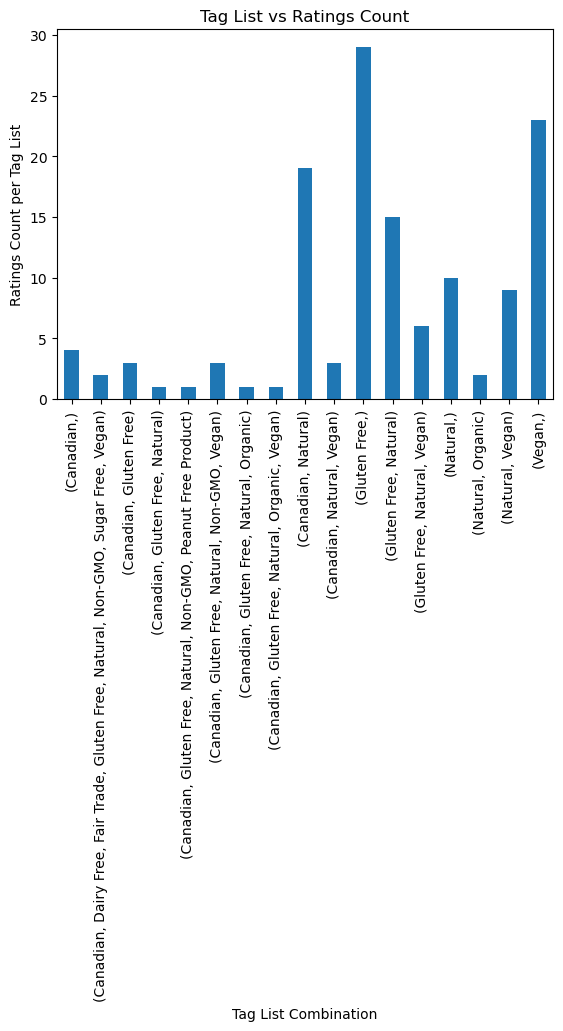

In [282]:
y = no_nan_values.groupby('tag_list')['rating'].count()
y.plot(kind= 'bar')
plt.xlabel('Tag List Combination')
plt.ylabel('Ratings Count per Tag List')
plt.title('Tag List vs Ratings Count')

### I noticed that the Tag_list with more tags had fewer ratings so I decided to zone in and focus on the tag combinations with more than 2 ratings

In [283]:
no_nan_values['rating_count'] = no_nan_values.groupby('tag_list')['rating'].transform('count')
more_than_two = no_nan_values[no_nan_values['rating_count'] > 2]


### Average Ratings for Products with more than 2 ratings recorded

In [284]:
more_than_two.groupby('tag_list')['rating'].mean().round(2).reset_index().sort_values('rating')

,tag_list,rating
4,"(Canadian, Natural, Vegan)",3.43
6,"(Gluten Free, Natural)",3.86
0,"(Canadian,)",3.90
1,"(Canadian, Gluten Free)",4.17
3,"(Canadian, Natural)",4.17
8,"(Natural,)",4.24
10,"(Vegan,)",4.41
7,"(Gluten Free, Natural, Vegan)",4.42
9,"(Natural, Vegan)",4.46
5,"(Gluten Free,)",4.52


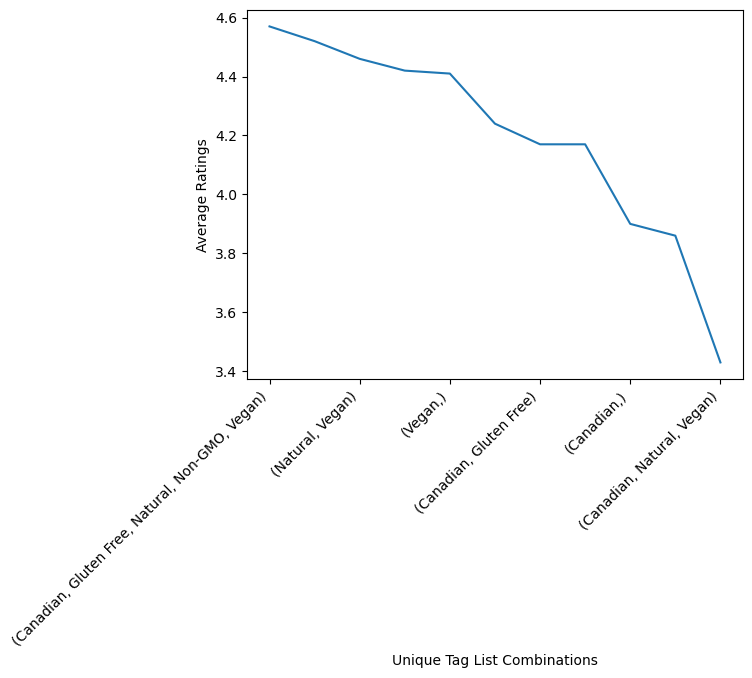

In [285]:

y = more_than_two.groupby('tag_list')['rating'].mean().round(2).sort_values(ascending=False)
y.plot(kind= 'line')
plt.xlabel('Unique Tag List Combinations')
plt.ylabel('Average Ratings')
plt.xticks(rotation=45, ha='right')
plt.show()

## Data Findings

- **Products with fewer tags have a higher amount of reviews** : Products with simpler tags list combinations appeal to a broader audience leading to more reviews and critism. Products with a higher amount of tags have smaller audience.
*Conclusion*: More Tags does not necessarily lead to more consumers.

- **Products with only the tags "Vegan", "Gluten Free", "Canadian, Natural" yielded the most reviews**: These tags brought in the most reviews meaning people are interested in these tags when shopping for makeup.
*Conclusion*: Makeup companies should invest more into their labs to make sure they are delivering products with these tags since they amonst the most reviewd.

- **Highest Average Ratings**: Products with tag list that include the words 'Natural', 'Vegan', 'Gluten Free', 'Canadian' and 'Non GMO' yielded the highest average ratings above 4.0 amongst the products with over 2 ratings.
*Conclusion* Consumers favor products with natural and ethical claims, as these are the products that recieved the highest ratings. Packaging should emphasize these ethical claims.
